# 01 - Data exploration

Before any strategy work: what is actually in the data?

This notebook checks coverage, verifies that adjusted prices differ from unadjusted ones in the
way they should, and looks at the correlation structure that determines whether a
cross-sectional ranking has anything to choose between.

All logic lives in `src/quant_platform/`. This notebook only calls it.

In [1]:
%matplotlib inline

import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Notebooks live in notebooks/; the package lives in src/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_platform import data, metrics, reporting, signals, validation
from quant_platform.returns import simple_returns, log_returns, cumulative_returns, rolling_volatility

reporting.apply_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 25)

UNIVERSE = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "DBC"]
print("quant_platform loaded from", ROOT / "src")

quant_platform loaded from C:\Users\monis\quant-research-platform\src


## Load the panel

Cached to Parquet on first run, with a provenance sidecar.

In [2]:
long = data.load_prices(
    symbols=UNIVERSE,
    start="2007-01-01",
    end="2025-12-31",
    data_dir=ROOT / "data",
    wide=False,
)
print(long.shape)
long.head()

(43011, 8)


,date,symbol,open,high,low,close,adjusted_close,volume
0,2007-01-03,DBC,24.270000,24.340000,23.680000,23.799999,19.330032,746800
1,2007-01-04,DBC,23.549999,23.700001,23.059999,23.180000,18.826475,428900
2,2007-01-05,DBC,23.049999,23.350000,22.850000,23.100000,18.761499,369800
3,2007-01-08,DBC,23.500000,23.559999,22.990000,23.219999,18.858963,275200
4,2007-01-09,DBC,22.650000,23.139999,22.480000,23.020000,18.696527,675600


## Validate

The checks that must pass before anything downstream is trustworthy.

In [3]:
report = data.validate_price_panel(long)

print("ok:      ", report["ok"])
print("errors:  ", report["errors"])
print("rows:    ", f"{report['n_rows']:,}")
print("symbols: ", report["n_symbols"])
print("span:    ", report["date_min"], "->", report["date_max"])
print("common history starts:", report["common_history_starts"])
report["coverage"]

ok:       True
errors:   []
rows:     43,011
symbols:  9
span:     2007-01-03 -> 2025-12-30
common history starts: 2007-01-03


,first,last,rows
symbol,,,
DBC,2007-01-03,2025-12-30,4779
EEM,2007-01-03,2025-12-30,4779
EFA,2007-01-03,2025-12-30,4779
GLD,2007-01-03,2025-12-30,4779
IWM,2007-01-03,2025-12-30,4779
QQQ,2007-01-03,2025-12-30,4779
SPY,2007-01-03,2025-12-30,4779
TLT,2007-01-03,2025-12-30,4779
VNQ,2007-01-03,2025-12-30,4779


## The three invariants

Every downstream function assumes these hold. State them as assertions, not as hope.

In [4]:
prices = data.to_wide(long, "adjusted_close")

assert prices.index.is_monotonic_increasing
assert not prices.index.duplicated().any()
assert prices.columns.is_unique

print("invariants hold:", prices.shape)
prices.tail(3)

invariants hold: (4779, 9)


,DBC,EEM,EFA,GLD,IWM,QQQ,SPY,TLT,VNQ
date,,,,,,,,,
2025-12-26,22.700001,54.516636,95.065636,416.739990,250.378143,622.420349,686.660889,85.450272,87.151978
2025-12-29,22.490000,54.377361,94.780151,398.600006,248.844528,619.407410,684.213867,85.771667,87.328522
2025-12-30,22.639999,54.596222,94.937660,398.890015,247.002182,617.970764,683.378357,85.567146,87.505066


## Adjusted vs unadjusted

This is the check that justifies using `adjusted_close` everywhere.

A momentum signal on unadjusted prices reads a dividend distribution as a price drop. For heavy
distributors like TLT and VNQ that is a systematic downward bias in the ranking — they would be
under-ranked against SPY for reasons that have nothing to do with total return.

In [5]:
raw = data.to_wide(long, "close")
adj = data.to_wide(long, "adjusted_close")

gap = pd.DataFrame({
    "unadjusted total return": raw.iloc[-1] / raw.iloc[0] - 1,
    "adjusted total return":   adj.iloc[-1] / adj.iloc[0] - 1,
})
gap["difference"] = gap["adjusted total return"] - gap["unadjusted total return"]
gap["annualised gap"] = (
    (1 + gap["adjusted total return"]) ** (252 / len(adj))
    - (1 + gap["unadjusted total return"]) ** (252 / len(adj))
)
gap.sort_values("difference", ascending=False).style.format("{:.2%}")

,unadjusted total return,adjusted total return,difference,annualised gap
QQQ,1332.54%,1568.44%,235.90%,0.93%
SPY,385.97%,591.19%,205.23%,2.04%
VNQ,15.69%,155.13%,139.44%,4.29%
EFA,31.19%,131.06%,99.87%,3.07%
IWM,217.34%,309.77%,92.44%,1.44%
TLT,-1.35%,77.41%,78.75%,3.14%
EEM,42.99%,112.50%,69.51%,2.15%
DBC,-4.87%,17.12%,22.00%,1.10%
GLD,540.48%,540.48%,0.00%,0.00%


The gap is the dividend stream. It is largest for the income-heavy holdings, which is exactly
where an unadjusted ranking would go wrong.

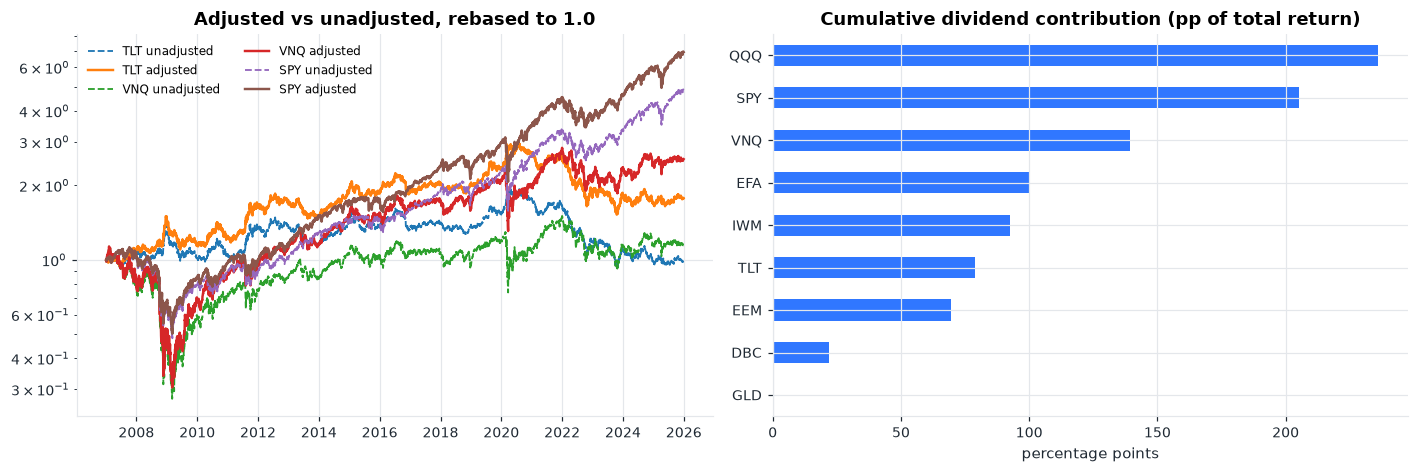

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for col in ["TLT", "VNQ", "SPY"]:
    axes[0].plot(raw.index, raw[col] / raw[col].iloc[0], label=f"{col} unadjusted", ls="--", lw=1.2)
    axes[0].plot(adj.index, adj[col] / adj[col].iloc[0], label=f"{col} adjusted", lw=1.6)
axes[0].set_title("Adjusted vs unadjusted, rebased to 1.0")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8, ncol=2)

(gap["difference"] * 100).sort_values().plot.barh(ax=axes[1], color="#0B5FFF", alpha=0.85)
axes[1].set_title("Cumulative dividend contribution (pp of total return)")
axes[1].set_xlabel("percentage points")
plt.tight_layout()

## Price history and cumulative returns

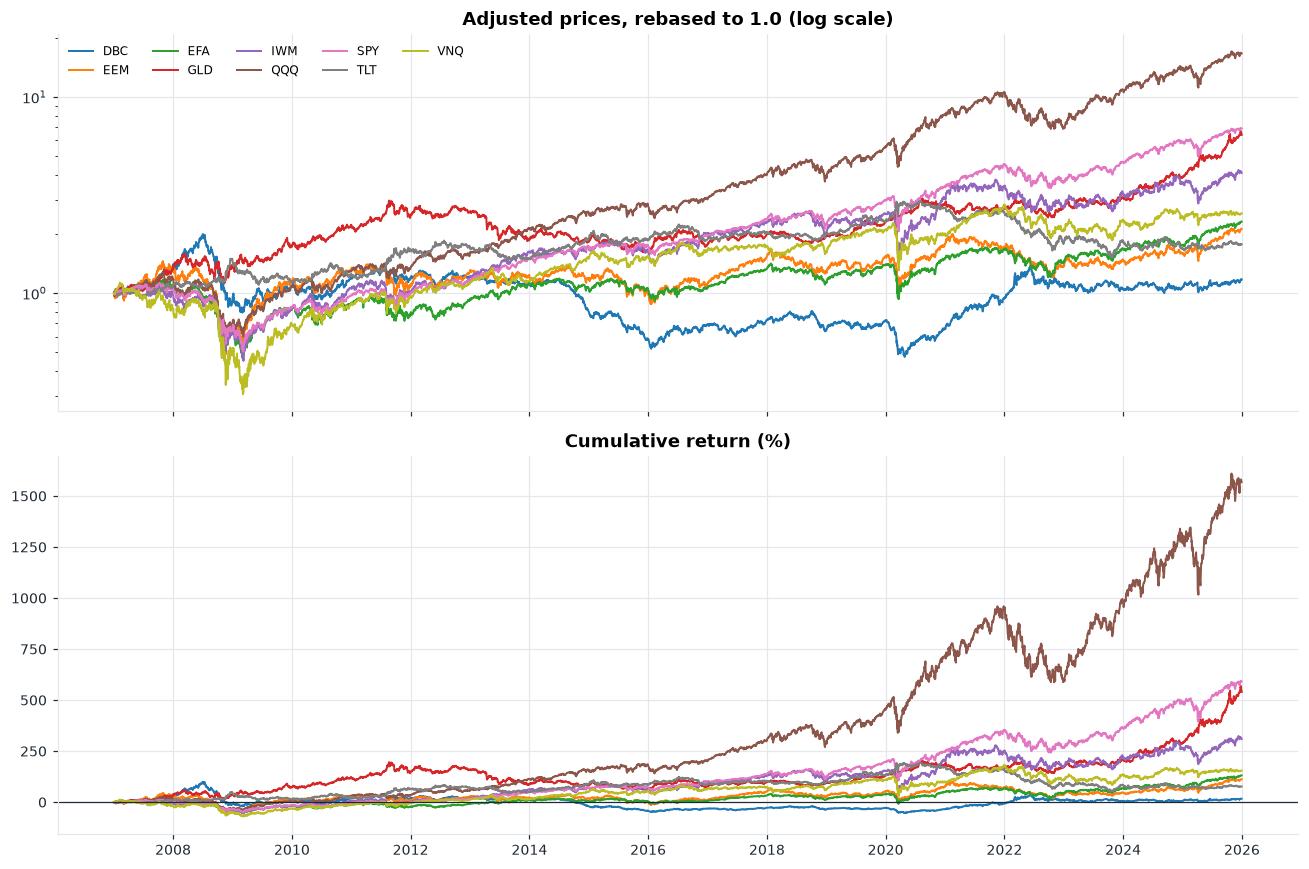

In [7]:
returns = simple_returns(prices)
cum = cumulative_returns(returns)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for col in prices.columns:
    axes[0].plot(prices.index, prices[col] / prices[col].iloc[0], label=col, lw=1.3)
axes[0].set_yscale("log")
axes[0].set_title("Adjusted prices, rebased to 1.0 (log scale)")
axes[0].legend(ncol=5, fontsize=8)

for col in cum.columns:
    axes[1].plot(cum.index, cum[col] * 100, label=col, lw=1.3)
axes[1].set_title("Cumulative return (%)")
axes[1].axhline(0, color="#1F2933", lw=0.8)
plt.tight_layout()

## Per-asset statistics

In [8]:
stats = pd.DataFrame({
    "CAGR":        returns.apply(metrics.annualized_return),
    "Volatility":  returns.apply(metrics.annualized_volatility),
    "Sharpe":      returns.apply(metrics.annualized_sharpe),
    "Max DD":      prices.apply(lambda s: metrics.maximum_drawdown(s / s.iloc[0])),
    "Skew":        returns.skew(),
    "Kurtosis":    returns.kurtosis(),
}).sort_values("Sharpe", ascending=False)
stats.round(3)

,CAGR,Volatility,Sharpe,Max DD,Skew,Kurtosis
QQQ,0.160,0.223,0.778,-0.534,-0.062,7.623
GLD,0.103,0.175,0.647,-0.456,-0.149,6.335
SPY,0.107,0.198,0.615,-0.552,-0.001,14.537
IWM,0.077,0.248,0.424,-0.586,-0.327,6.169
VNQ,0.051,0.298,0.315,-0.731,0.017,16.395
EFA,0.045,0.217,0.312,-0.610,-0.040,13.923
EEM,0.041,0.280,0.281,-0.664,0.564,19.136
TLT,0.031,0.152,0.275,-0.484,0.082,3.215
DBC,0.008,0.192,0.140,-0.764,-0.405,3.320


## Correlation structure

A cross-sectional ranking is only useful if the assets can actually diverge. If everything were
correlated at 0.95, "top 3 of 9" would be a coin flip dressed up as a signal.

mean off-diagonal correlation: 0.373
range: -0.317 to 0.924


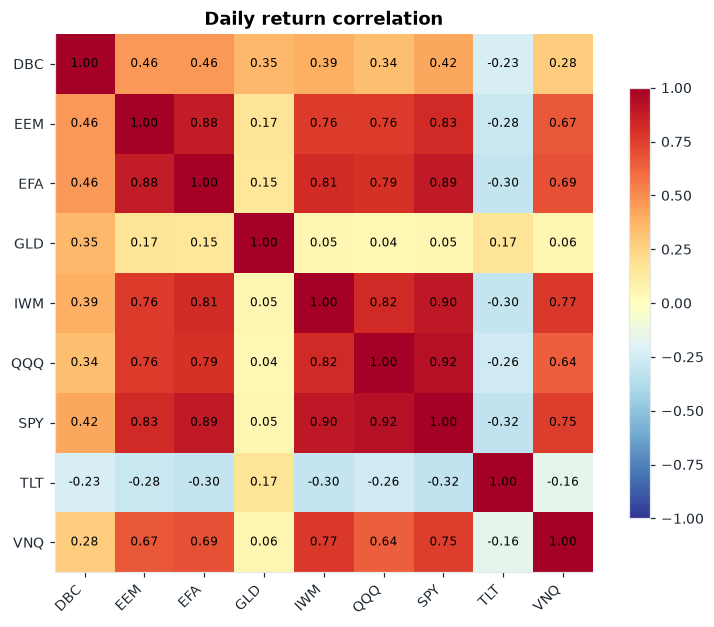

In [9]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7.2, 5.8))
im = ax.imshow(corr, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Daily return correlation")
plt.tight_layout()

off = corr.to_numpy()[~np.eye(len(corr), dtype=bool)]
print(f"mean off-diagonal correlation: {off.mean():.3f}")
print(f"range: {off.min():.3f} to {off.max():.3f}")

TLT and GLD are the diversifiers — negative or near-zero against the equity block. That is what
lets a top-3 selection rotate genuinely defensively rather than just picking the highest-beta
equity sleeve.

## Missing data and rolling volatility

In [10]:
print("missing values per symbol:")
print(prices.isna().sum().to_string())

gaps = prices.index.to_series().diff().dt.days
print(f"\nlargest calendar gap between observations: {gaps.max():.0f} days")
print(f"observations: {len(prices):,} over {(prices.index[-1] - prices.index[0]).days / 365.25:.1f} years")

missing values per symbol:
DBC    0
EEM    0
EFA    0
GLD    0
IWM    0
QQQ    0
SPY    0
TLT    0
VNQ    0

largest calendar gap between observations: 5 days
observations: 4,779 over 19.0 years


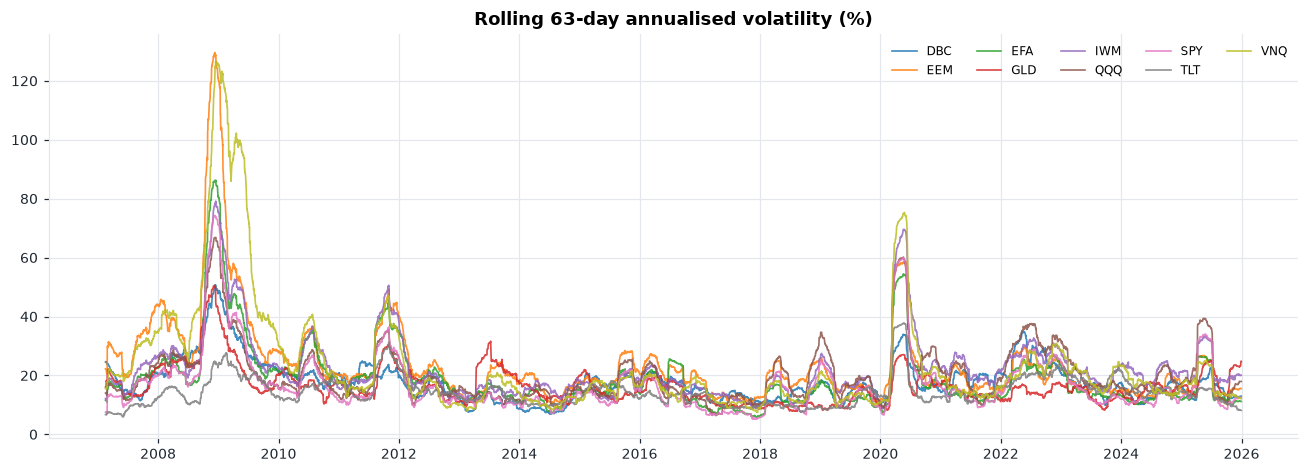

In [11]:
vol = rolling_volatility(returns, window=63)

fig, ax = plt.subplots(figsize=(12, 4.4))
for col in vol.columns:
    ax.plot(vol.index, vol[col] * 100, lw=1.1, label=col, alpha=0.85)
ax.set_title("Rolling 63-day annualised volatility (%)")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()

## Takeaways

1. Coverage is complete for all nine ETFs from 2007 — no mid-sample entry to distort the ranking.
2. Adjusted and unadjusted series diverge materially for income-heavy holdings. Using adjusted
   prices is not optional.
3. Correlations are diverse enough that the cross-sectional ranking has real choices to make.
4. Volatility is strongly time-varying and clusters — relevant to the volatility-targeting
   extension in the report's next-experiments list.

Next: `02_momentum_research.ipynb`.